In [2]:
import pandas as pd
import numpy as np

# Load raw dataset
df = pd.read_csv('/workspaces/ML_01_video_game_prediction/video_game_analysis/src/data/Video_Games_Sales_as_at_22_Dec_2016.csv')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [3]:
#Missing value check
df.isnull().sum().sort_values(ascending=False)


User_Count         9129
Critic_Count       8582
Critic_Score       8582
Rating             6769
User_Score         6704
Developer          6623
Year_of_Release     269
Publisher            54
Name                  2
Genre                 2
NA_Sales              0
Platform              0
JP_Sales              0
EU_Sales              0
Other_Sales           0
Global_Sales          0
dtype: int64

**Observations**
- Fill User_Score, Critic_Score with median
- Too much valuable data would be lost if dropped

---

Text(0.5, 1.0, 'Distribution of Global Sales')

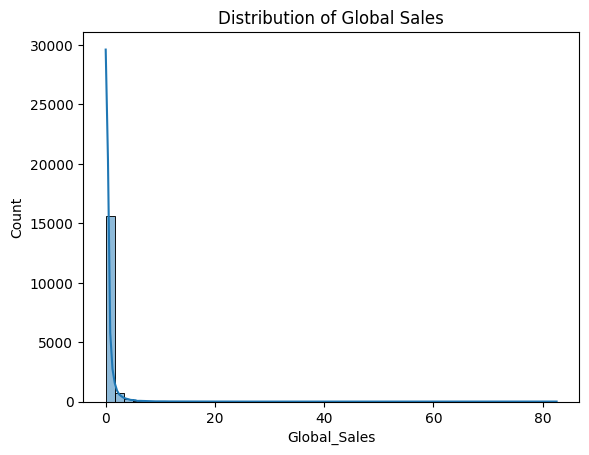

In [4]:
#Visualize Distributions
import seaborn as sns
import matplotlib.pyplot as plt

# Target distribution
sns.histplot(df['Global_Sales'], bins=50, kde=True)
plt.title("Distribution of Global Sales")


Text(0.5, 1.0, 'Feature Correlations')

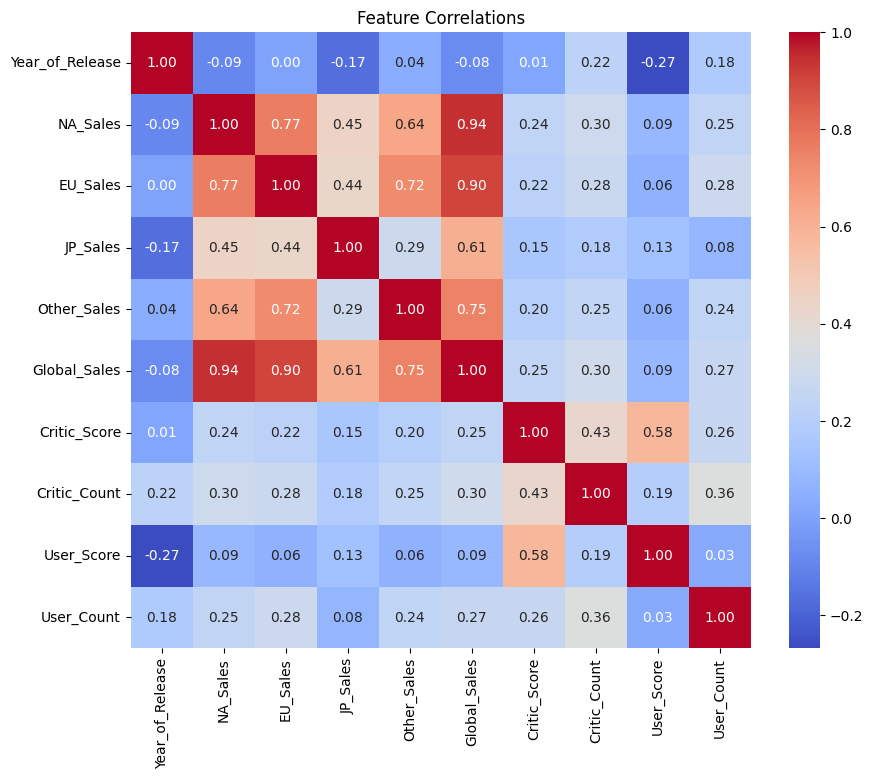

In [7]:
#Correlation heatmap
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlations")


**Observations**
- Global_Sales correlates well with Critic_Score, User_Score
- Keep those features
- consider combining into Total_Rating

---

Text(0.5, 1.0, 'Top 10 Platforms by Count')

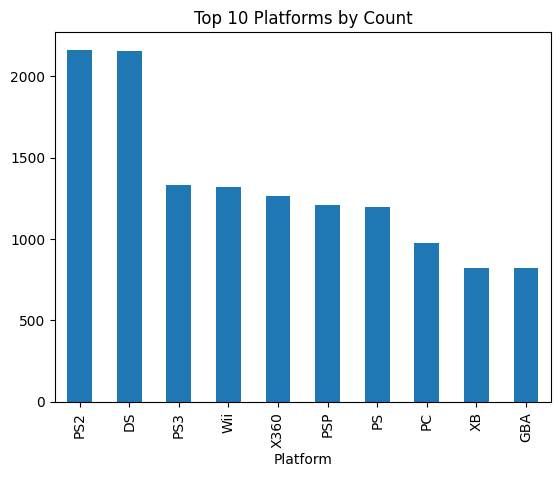

In [6]:
#Categorical Counts

df['Platform'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Platforms by Count")
